In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path 
import os
os.environ['MUJOCO_GL'] = 'egl'
os.environ['MKL_SERVICE_FORCE_INTEL'] = '1'
from tqdm import tqdm
from IPython.display import Video

import torch
import numpy as np

import sys
sys.path.append("/mnt/home/focus")

os.chdir("/mnt/home/focus")
print(f"Working directory: {os.getcwd()}")

import env
from env.make import make

import matplotlib.pyplot as plt
import matplotlib.animation as animation

Working directory: /mnt/home/focus


/opt/conda/lib/python3.11/site-packages/robosuite/__init__.py:7: DeprecationWarning: The 'warn' method is deprecated, use 'warning' instead
  ROBOSUITE_DEFAULT_LOGGER.warn("No private macro file found!")
[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /opt/conda/lib/python3.11/site-packages/robosuite/scripts/setup_macros.py (__init__.py:9)
/opt/conda/lib/python3.11/site-packages/warp_maniskill/warp/codegen.py:13: DeprecationWarning: the imp module is deprecated in favour of importlib and slated for removal in Python 3.12; see the module's documentation for alternative uses
  import imp
/opt/conda/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: DeprecationWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", D

In [2]:
# LOAD CONFIG FILE FOR EXPERIMENT
# to handle multilple config file, just load one of the latest config file and then duplicate for each env/agent modifying the necessary parameters

# from hydra import compose, initialize
# from omegaconf import OmegaConf

# initialize(config_path="../../../../public/projects/mazpie/online_reacher_benchmark_1/pretrain/318a11550ec6f5c89516b04dfc3756f2/code/exp_local/2024.03.12/175058_dreamer_reacher_hard_/.hydra", job_name="config")
# cfg = compose(config_name="config")

In [2]:
# INSTANTIATE ENVIRONMENT
from omegaconf import OmegaConf

global_step = 0
action_repeat = 2
snapshot_ts = global_step * action_repeat
seed = 0

envs_name = {"dmc": ["reacher_easy"]}
runs = {"reacher_easy": {"1": ["38f136942e4a8b219ba3471b9d48117e", "38f136942e4a8b219ba3471b9d48117e"] , "2": ["002d875d9675a3f7bbcb70224069b8d0", "78423885deb37e3ce845c9410e26ce19"] , "3":["202ca7953bcd7528b8be63285053dd0f", "ad021d575129b3d6bbef4af7ffcf8416"] , "5": ["da844415cf783837223393ce1ad50882"]} }
                # "reacher_hard": {"1": [""], "2": , "3": , "5": ,
                # "CustomLift": {"1": , "2": , "3": , "5": }} # env | id number | run number

configs = {"reacher_easy":{}}
envs = {"reacher_easy":{}}

# For each config have a unique environment to avoid issues with different configurations
for k, v in envs_name.items():
    for task in v:
        for id in runs[task]:
            # for run in config_files[task][id]:
            run = runs[task][id][0]
            base_path = f"/mnt/public/projects/mazpie/offline_reacher_benchmark_{id}/offline/{run}/code/exp_local/"
            for subdir, dirs, files in os.walk(base_path):
                    if 'hydra' in subdir:
                        print(subdir)
                        cfg = OmegaConf.load(subdir + "/config.yaml")
                        print(f"{k} - {task}")
                        env = make(k, task, action_repeat=action_repeat, seed=seed, env_config=cfg.env)
                        env.reset()
                        envs[task][id] = env
                        configs[task][id] = cfg
                        


/mnt/public/projects/mazpie/offline_reacher_benchmark_1/offline/38f136942e4a8b219ba3471b9d48117e/code/exp_local/2024.03.19/111952_dreamer_reacher_easy_/.hydra
dmc - reacher_easy
/mnt/public/projects/mazpie/offline_reacher_benchmark_2/offline/002d875d9675a3f7bbcb70224069b8d0/code/exp_local/2024.03.19/112051_skill_dreamer_reacher_easy_/.hydra
dmc - reacher_easy
/mnt/public/projects/mazpie/offline_reacher_benchmark_2/offline/002d875d9675a3f7bbcb70224069b8d0/code/exp_local/2024.03.19/154134_skill_dreamer_reacher_easy_/.hydra
dmc - reacher_easy
/mnt/public/projects/mazpie/offline_reacher_benchmark_3/offline/202ca7953bcd7528b8be63285053dd0f/code/exp_local/2024.03.19/112620_dreamer_reacher_easy_/.hydra
dmc - reacher_easy
/mnt/public/projects/mazpie/offline_reacher_benchmark_5/offline/da844415cf783837223393ce1ad50882/code/exp_local/2024.03.19/112858_skill_focus_reacher_easy_/.hydra
dmc - reacher_easy
/mnt/public/projects/mazpie/offline_reacher_benchmark_5/offline/da844415cf783837223393ce1ad508

In [4]:
# IMPORT AGENT MODEL (WM + Actor Critic) (last snapshot for each model)
from copy import deepcopy 

models = {"reacher_easy": {}}

def load_agent(agent_path):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    with agent_path.open('rb') as f:
        obj = torch.load(f, map_location=torch.device(device))
        agent = obj['agent']    
        step = obj['_global_step']
    return agent, step

def init_agent(cfg):
    from utils import make_dreamer_agent
    return make_dreamer_agent(env.obs_space, env.action_spec(), cfg)

agents = {"reacher_easy": {}}
device = 'cuda' if torch.cuda.is_available() else 'cpu'

for task in runs.keys():
    for id in runs[task].keys():
        agents[task][id] = []
        for run in runs[task][id]:
            agent_path = Path(f"/mnt/public/projects/mazpie/offline_reacher_benchmark_{id}/offline/{run}/code/last_snapshot.pt")
            agent, step = load_agent(agent_path)
            # agent = init_agent(configs[task][id])
            agent.device = device
            agent.wm.device = device
            agent.wm.rssm.device = device
            agent.wm.rssm._cell.device = device
            agent.is_finetune = True
            agent.wm.rssm._full_posterior = True
            agent.cfg.agent.only_expl_during_training = False
            agents[task][id].append(deepcopy(agent))
        


In [15]:
# TEST DIRECTORIES GENERATION

# from os import listdir
# from os.path import isfile, join
# import os
# import random
# import shutil
# # Automate the process of test episodes collections, get 100 random episodes
# envs = ["reacher_easy", "reacher_hard", "CustomLift"]

# for env in envs:
#     dir = f"/mnt/home/datasets/{env}/focus"
#     save_dir = f"/mnt/home/datasets/{env}/test_episodes"
    
#     if not os.path.exists(save_dir):
#         os.makedirs(save_dir)
    
#     all_files = [f for f in listdir(dir) if isfile(join(dir, f))]
    
#     files = random.sample(all_files, 100)
#     for file in files:
#         shutil.copy2(f"{dir}/{file}", f"{save_dir}/{file}") 

In [5]:
# LOADING FROM REPLAY BUFFER

# from replay_buffer import ReplayBuffer, make_replay_loader
# from env.utils import obs_specs
# from dm_env import specs

# train_obs_spec = env.obs_space

# meta_specs = agent.get_meta_specs()

# data_specs = (*obs_specs(train_obs_spec),
#             env.action_spec(),
#             specs.Array((1,), np.float32, "reward"),
#             specs.Array((1,), np.float32, "discount"))

# # cfg.dataset_dir = "/mnt/public/projects/mazpie/online_reacher_benchmark_1/pretrain/861fcdbba354d1d39ed21ec4a6201d73/code/buffer"
# cfg.dataset_dir = "/mnt/home/datasets/reacher_easy/test_episodes"

# # create data storage and load data
# replay_storage = ReplayBuffer(
#     data_specs,
#     meta_specs,
#     Path(cfg.dataset_dir),
#     length=cfg.batch_length,
#     **cfg.replay,
#     device=cfg.device,
#     load_first=True
# )

# # create replay buffer
# replay_loader = make_replay_loader(
#     replay_storage,
#     cfg.batch_size,
#     cfg.replay_buffer_num_workers,
# )

Incosistency between min/max/length in the replay buffer. Defaulting to (length):  32


In [52]:
# LOAD TEST EPISODES

from env.utils import obs_specs
from dm_env import specs
from os import listdir
from os.path import isfile, join

train_obs_spec = env.obs_space

meta_specs = agent.get_meta_specs()

data_specs = (*obs_specs(train_obs_spec),
            env.action_spec(),
            specs.Array((1,), np.float32, "reward"),
            specs.Array((1,), np.float32, "discount"))

# cfg.dataset_dir = "/mnt/public/projects/mazpie/online_reacher_benchmark_1/pretrain/861fcdbba354d1d39ed21ec4a6201d73/code/buffer"
cfg.dataset_dir = "/mnt/home/datasets/reacher_easy/test_episodes"

episodes = {"reacher_easy": [], "reacher_hard": [], "CustomLift": []}
all_files = [f for f in listdir(cfg.dataset_dir) if isfile(join(cfg.dataset_dir, f))]

for file in all_files:
    filename = Path(f"{cfg.dataset_dir}/{file}")
    with filename.open("rb") as f:
        episode = np.load(f)
        episode = {k: episode[k] for k in episode.keys()}
        episode["is_terminal"] = episode["discount"] == 0
        episode["is_first"] = np.zeros(len(episode["action"]), bool)
        episode["is_first"][0] = True
        episode = {
                k: torch.as_tensor(np.copy(v), device="cuda:0").unsqueeze(0)
                for k, v in episode.items()
            }
        episodes["reacher_easy"].append(episode)

In [62]:
from scipy import ndimage
import matplotlib.pyplot as plt
from tqdm import tqdm

feat = []
recon = []
agent_state = None

def det(t):
    return t.detach().cpu().numpy()

def mean_std(t):
    if isinstance(t, torch.Tensor):
        t = t.detach().cpu().numpy()
        
    mean = np.nanmean(np.where(np.isclose(t,0, atol=1e-2), np.nan, t))
    std = np.nanstd(np.where(np.isclose(t,0, atol=1e-2), np.nan, t))
    return mean, std

metrics = {"prior_error": {}, "prior_recon_error": {}, "recon_masked_error": {}, "prior_recon_masked_error": {}}
prior_recons = {"reacher_easy": {}}
post_recons = {"reacher_easy": {}}

imag_start_step = 50
error_steps = [1, 5, 10, 25, 50, 75, 100]
metrics = {k: [[] for _ in range(len(error_steps))] for k in metrics.keys()} 

In [63]:
def merge_rgb_layers(data, seg):
    merged = torch.zeros((list(data.shape)[:2] + list(data.shape)[3:]), device=data.device)
    for instance in range(data.shape[2]):
        # seg_channel = seg[:,:,instance].unsqueeze(2)
        merged = merged + data[:,:,instance] 
    return merged

num_episodes = 1
task = "reacher_easy"

metrics = {k: [{id: [{"mean": 0, "std": 0} for _ in range(len(runs[task][id]))] for id in runs[task].keys()} for _ in range(len(error_steps))] for k, v in metrics.items()}

for id in tqdm(runs[task].keys()):
    # id ="5" # testing purposes
    for r_i, run in enumerate(runs[task][id]):
        for episode in tqdm(episodes["reacher_easy"][:num_episodes]):
            agent = agents[task][id][r_i]
            data = agent.wm.preprocess(episode)
            truth = data["rgb"] + 0.5
            with torch.no_grad():
                # initialize latent state for each observation, fake zero action
                decoder_head = "object_decoder" if id=="5" else "decoder"
                decoder = agent.wm.heads[decoder_head] # B, T, C, H, W
                embed = agent.wm.encoder(data)
                
                post, prior = agent.wm.rssm.observe(
                    embed,
                    data["action"],
                    data["is_first"],
                )
                
                recon = decoder(agent.wm.rssm.get_feat(post), masks=data["segmentation"])["rgb"].mean
                if id == "5": recon = merge_rgb_layers(recon, data["segmentation"]) # need to merge rgb segmentation layers into a single | input shape [1, 10, 2, 3, 64, 64]
                recon += 0.5
                
                post_recons[task][id] = recon
                init = {k: v[:, imag_start_step] for k, v in post.items()}
                for i, s in enumerate(error_steps):
                    # mse errors in the predictions
                    pred_prior = agent.wm.rssm.imagine(data["action"][:, imag_start_step+1:imag_start_step+s+1], init)
                    seg = data["segmentation"][:, imag_start_step+1:imag_start_step+s+1]
                    prior_recon = decoder(agent.wm.rssm.get_feat(pred_prior), masks=seg)["rgb"].mean
                    if id == "5": prior_recon = merge_rgb_layers(prior_recon, seg)  # need to merge rgb segmentation layers into a single | input shape [1, 10, 2, 3, 64, 64]
                    prior_recon += 0.5
                    
                    prior_recons[task][id] = prior_recon
                  
                    prior_error = torch.abs(agent.wm.rssm.get_feat(pred_prior)[:, -1] - agent.wm.rssm.get_feat(prior)[:, imag_start_step + s])
                    
                    mean, std = mean_std(prior_error)
                    metrics["prior_error"][i][id][r_i]["mean"] += mean / num_episodes
                    metrics["prior_error"][i][id][r_i]["std"] += std / num_episodes
                    
                    prior_recon_error = torch.abs((prior_recon[:, -1]) - truth[:, imag_start_step + s])
                    
                    mean, std = mean_std(prior_recon_error)
                    metrics["prior_recon_error"][i][id][r_i]["mean"] += mean / num_episodes
                    metrics["prior_recon_error"][i][id][r_i]["std"] += std / num_episodes
                                        
                    # mse objects errors in the predictions
                    # Mask of object -> dilate mask -> compute mse over selected region
                    if "segmentation" in data.keys():
                        seg = data["segmentation"][:,:,0]
                        struct = np.array([[[[0, 1, 0], [1, 1, 1], [0, 1, 0]]]])
                        dilated_seg = ndimage.binary_dilation(seg.detach().cpu().numpy(), struct, iterations=2)
                        dilated_seg_rgb_axis = np.repeat(dilated_seg[:, imag_start_step + s, np.newaxis], 3, axis=1)
                        
                        truth_masked = truth[:, imag_start_step + s].detach().cpu().numpy() * dilated_seg_rgb_axis
                        recon_masked = recon[:, imag_start_step + s].detach().cpu().numpy() * dilated_seg_rgb_axis
                        prior_recon_masked = prior_recon[:, -1].detach().cpu().numpy() * dilated_seg_rgb_axis

                        recon_masked_error = np.abs(truth_masked - recon_masked)  # mean over the mask
                        # recon_masked_metrics = {"mean": np.sum(recon_masked_error) / (np.sum(dilated_seg_rgb_axis)) ,"std": np.nanstd(np.where(np.equal(recon_masked_error,0), np.nan, prior_recon_masked_error))}
                        mean, std = mean_std(recon_masked_error)
                        metrics["recon_masked_error"][i][id][r_i]["mean"] += mean / num_episodes
                        metrics["recon_masked_error"][i][id][r_i]["std"] += std / num_episodes           
                                
                        prior_recon_masked_error = np.abs(truth_masked - prior_recon_masked)  # mean over the mask
                        # prior_recon_masked_metrics = {"mean": np.sum(prior_recon_masked_error) / (np.sum(dilated_seg_rgb_axis)) ,"std": np.nanstd(np.where(np.equal(prior_recon_masked_error,0), np.nan, prior_recon_masked_error))}
                        mean, std = mean_std(prior_recon_masked_error)
                        metrics["prior_recon_masked_error"][i][id][r_i]["mean"] += mean / num_episodes
                        metrics["prior_recon_masked_error"][i][id][r_i]["std"] += std / num_episodes                    


  0%|          | 0/4 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:17<00:00,  4.36s/it]


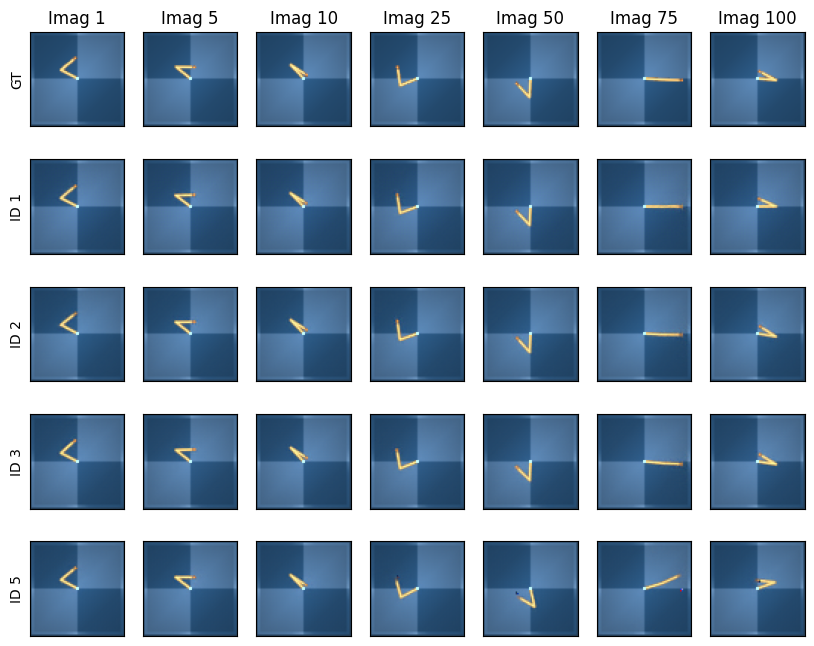

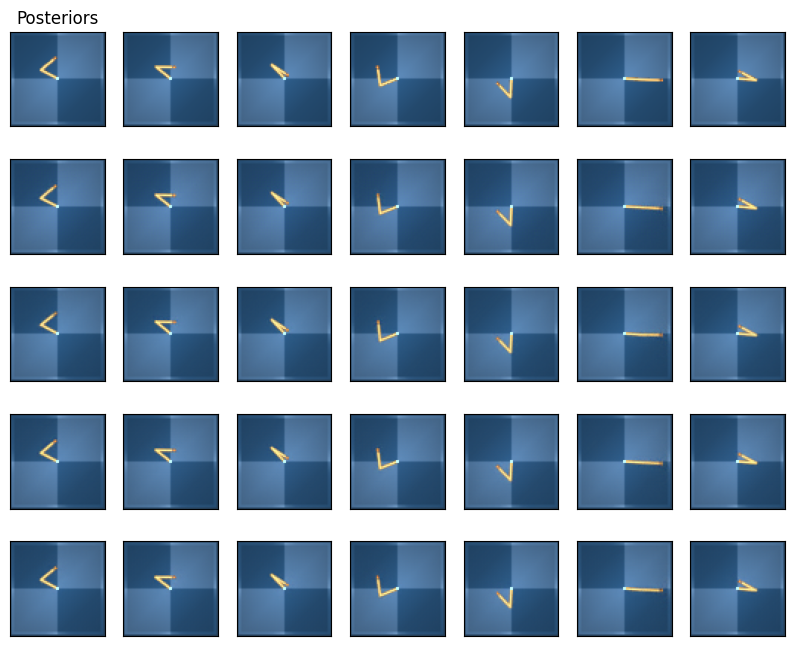

In [74]:
fig1, axs1 = plt.subplots(5, len(error_steps), figsize=(10, 8))
fig2, axs2 = plt.subplots(5, len(error_steps), figsize=(10, 8))

axs1[0, 0].set_ylabel(f"GT")
for i, id in enumerate(runs[task].keys()):
    axs1[i+1, 0].set_ylabel(f"ID {id}")

for i, s in enumerate(error_steps):
    axs1[0, i].imshow(det(truth[0, imag_start_step + s].permute(1,2,0)))
    axs1[0, i].set_title(f"Imag {s}")
    axs1[0, i].set_xticks([])
    axs1[0, i].set_yticks([])
    
    for y, id in enumerate(runs[task].keys()):
        axs1[y+1, i].imshow(det(prior_recons[task][id][0, s-1].permute(1,2,0)))
        axs1[y+1, i].set_xticks([])
        axs1[y+1, i].set_yticks([])

        
    axs2[0, i].imshow(det(truth[0, imag_start_step + s].permute(1,2,0)))
    axs2[0, 0].set_title(f"Posteriors")
    axs2[0, i].set_xticks([])
    axs2[0, i].set_yticks([])

    
    
    for y, id in enumerate(runs[task].keys()):
        axs2[y+1, i].imshow(det(post_recons[task][id][0, imag_start_step + s].permute(1,2,0)))
        axs2[y+1, i].set_xticks([])
        axs2[y+1, i].set_yticks([])

    # axs1[1, i].imshow(det(recon[0, imag_start_step + s].permute(1,2,0)))
    # axs2[0, i].imshow(dilated_seg[0][imag_start_step + s])
    # axs2[1, i].imshow(truth_masked[0].transpose(1,2,0))
    # axs2[2, i].imshow(recon_masked[0].transpose(1,2,0))
    # axs2[3, i].imshow(prior_recon_masked[0].transpose(1,2,0))


[0.029788995161652565, 0.03667024150490761, 0.023648696020245552, 0.024525359272956848, 0.03344713896512985, 0.09811171889305115, 0.04467592388391495]
[0.04295496642589569, 0.0671481192111969, 0.029927412047982216, 0.030005980283021927, 0.051284030079841614, 0.1763831526041031, 0.08001947402954102]
[0.03346247971057892, 0.038373515009880066, 0.037343546748161316, 0.0462467297911644, 0.060090720653533936, 0.0515458807349205, 0.034591082483530045]
[0.028953971341252327, 0.04254395142197609, 0.03922279551625252, 0.06379412114620209, 0.06932801753282547, 0.08774421364068985, 0.03323417156934738]
[0.019055256620049477, 0.01706315577030182, 0.022636478766798973, 0.024621032178401947, 0.03939863666892052, 0.03791601583361626, 0.02988399751484394]
[0.017315642908215523, 0.014144944958388805, 0.0327630490064621, 0.03556488826870918, 0.07414434105157852, 0.07520372420549393, 0.05426445230841637]
[0.028389928862452507, 0.04732273891568184, 0.12000089138746262, 0.08646847307682037, 0.1417002528905

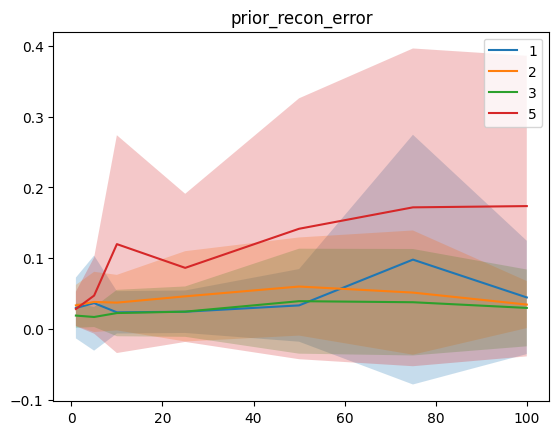

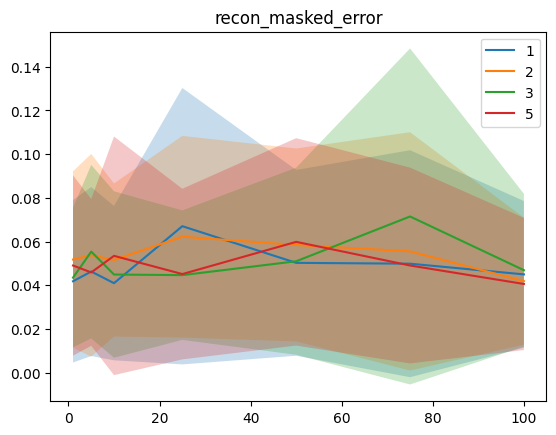

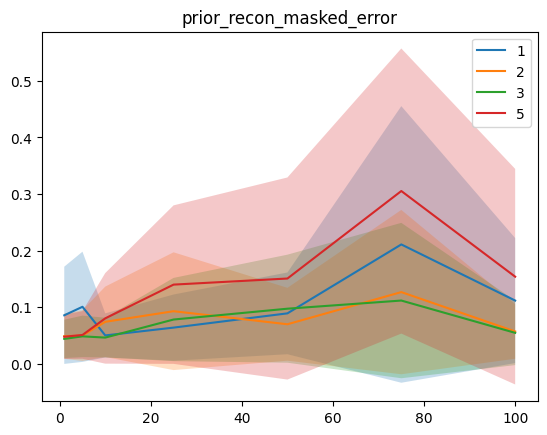

In [75]:
# for each img steps get a single mean value (with all the episodes)

# means = {}
# stds = {}

# for k, v in metrics.items():
#     means[k] = []
#     stds[k] = []
#     for i in range(len(v)):
#         means[k].append(np.array([x["mean"] for x in v[i]]).mean())
#         stds[k].append(np.array([x["std"] for x in v[i]]).mean())
        
plt.figure()
for id in runs[task].keys():
    
    means = [x[id][0]["mean"] for x in metrics["prior_recon_error"]]
    stds = [x[id][0]["std"] for x in metrics["prior_recon_error"]]
    print(means)
    print(stds)
    
    plt.plot(error_steps, means, label=id)
    plt.fill_between(error_steps, np.subtract(means, stds), np.add(means, stds), alpha=0.25)
    plt.legend()
    plt.title("prior_recon_error")
    
    
# plt.plot(error_steps, means["prior_recon_error"])
# plt.fill_between(error_steps, np.subtract(means["prior_recon_error"], stds["prior_recon_error"]), np.add(means["prior_recon_error"], stds["prior_recon_error"]), alpha=0.8)

plt.figure()
for id in runs[task].keys():
    
    means = [x[id][0]["mean"] for x in metrics["recon_masked_error"]]
    stds = [x[id][0]["std"] for x in metrics["recon_masked_error"]]
    print(means)
    print(stds)
    
    plt.plot(error_steps, means, label=id)
    plt.fill_between(error_steps, np.subtract(means, stds), np.add(means, stds), alpha=0.25)
    plt.legend()
    plt.title("recon_masked_error")
    
# plt.figure()
# plt.plot(error_steps, means["recon_masked_error"])
# plt.fill_between(error_steps, np.subtract(means["recon_masked_error"], stds["recon_masked_error"]), np.add(means["recon_masked_error"], stds["recon_masked_error"]), alpha=0.8)

plt.figure()
for id in runs[task].keys():
    
    means = [x[id][0]["mean"] for x in metrics["prior_recon_masked_error"]]
    stds = [x[id][0]["std"] for x in metrics["prior_recon_masked_error"]]
    print(means)
    print(stds)
    
    plt.plot(error_steps, means, label=id)
    plt.fill_between(error_steps, np.subtract(means, stds), np.add(means, stds), alpha=0.25)
    plt.legend()
    plt.title("prior_recon_masked_error")
    
# plt.figure()
# plt.plot(error_steps, means["prior_recon_masked_error"])
# plt.fill_between(error_steps, np.subtract(means["prior_recon_masked_error"], stds["prior_recon_masked_error"]), np.add(means["prior_recon_masked_error"], stds["prior_recon_masked_error"]), alpha=0.8)
        

tensor([[[ 0.0000,  0.0000],
         [-1.0000, -0.5780],
         [-1.0000,  0.7879],
         ...,
         [-1.0000,  1.0000],
         [ 1.0000,  0.1686],
         [ 1.0000,  0.0573]]], device='cuda:0')